In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math as math

In [ ]:
atoms = 2000
Temp = 15000
kb = 1.38e-23
NA = 6.022e23
MSI = 28.0855/NA #use cgs system
angle = 0.3 #radians
sinangle = math.sin(angle)
cosangle = math.cos(angle)


def trajtoarr(filename, dt,atoms=2000):
    timeflag =False
    atomflag=False
    count = 0
    atomlist = []
    tempatomlist=[]
    timestep=0
    with open(filename, 'r') as file:
        for line in file:
            if "ITEM" in line:
                if "ITEM: TIMESTEP" in line:
                    count += 1
                    timeflag = True
                    atomflag=False
                    tempatomlist.append(float(dt*timestep))
                    atomlist.append(tempatomlist)
                    tempatomlist=[]
                elif "ITEM: ATOMS id type vx vy vz" in line:
                    atomflag = True
                    timeflag=False
                else:
                    timeflag = False
                    atomflag = False
            if timeflag and ("ITEM" not in line):
                timestep = float(line.strip())
            if atomflag and ("ITEM" not in line):
                vz = float(line.strip().split(" ")[-1])
                vy = float(line.strip().split(" ")[-2])
                tempatomlist.append(sinangle*vy+cosangle*vz)
                count += 1
    tempatomlist.append(float(dt*timestep))
    atomlist.append(tempatomlist)
    atomlist.pop()
    atomlist.pop(0)
    atomlist.pop()
    atomarr = np.array(atomlist)
    print(atomarr)
    return atomarr
def logtoarr(filename):
    startlogstr = "   Step          Time           Temp         c_tempH        c_tempSi        TotEng         PotEng         KinEng         Press           v_k0           v_dt        v_collfreq       v_ccs "
    endlogstr = "Loop time of "
    templist=[]
    dataflag=False
    with open(filename, 'r') as file:
        for line in file:
            if  "ERROR" in list(filter(None, line.split(" "))):
                break
            if dataflag:
                dataline = list(filter(None, line.split(" ")))
                dataline[-1] = dataline[-1][:-1]
                dataline = list(filter(None, dataline))
                templist.append(dataline)
            if startlogstr in line:
                dataflag=True
                templist=[]
            if endlogstr in line:
                dataflag=False
    print(templist)

    templist.pop()
    templist.pop()
    templist.pop()
    templist.pop()
    templist.pop()
    templist.pop(0)    # print(templist
    return np.array(templist,dtype=np.float64)


runlist = ["run10_15","run10_15b","run10_17","run10_18","run10_19","run10_22","run10_28","run11_5","run4_15","run4_22","run4_29"]
drop22 = [[0,0],[1,0],[4,0],[5,0],[6,0],[7,0],[8,0],[9,0]]
drop28=[]
for i in range(10):
    for j in range(1,4):
        drop22.append([i,j])
for i in range(2):
    for j in range(1,4):
        drop28.append([i,j])
drop115=[]
for i in range(2):
    for j in range(1,4):
        drop115.append([i,j])
drop45=[[0,1],[0,3],[2,1],[3,1]]
drop422=[[0,3],[1,2],[1,3]]
dropdict = {"run10_15":[[0,0],[0,1],[0,2],[1,2],[3,2],[4,2],[5,0],[5,1],[5,2],[5,3]],"run10_15b":[[0,0],[1,1],[1,2],[1,3],[2,0],[2,2],[2,3],[3,2],[3,3],[4,1],[4,2],[5,1],[5,2]],"run10_17":[[0,0],[1,3],[3,0],[3,1],[4,1],[4,2],[4,3],[5,1],[5,3],[6,2],[6,3]],"run10_18":[[0,2],[0,3],[1,0],[1,1],[3,2],[4,2],[5,1],[5,3]],"run10_19":[[0,0],[1,0],[1,1],[5,1]],"run10_22":drop22,"run10_28":drop28,"run11_5":drop115,"run4_15":drop45,"run4_22":drop422,"run4_29":[]}#[[0,2],[1,0]]
vel429float=np.logspace(3,8,60)
# vel429=[]
# for i in range(60):
vel429 = vel429float
thermdict = {"run10_15":81,"run10_15b":81,"run10_17":81,"run10_18":81,"run10_19":21,"run10_22":21,"run10_28":21,"run11_5":21,"run4_15":21,"run4_22":21,"run4_29":21}
veldict = {"run10_15":[2e7,3e7,4e7,5e7,6e7,8e7],"run10_15b":[1e2,1e3,1e4,1e5,1e6,1e7,1e8],"run10_17":[1.5e7,2e6,2.5e7,3e6,3.5e7,4.5e7,6e6,8e6],"run10_18":[1.5e6,2.5e6,4e6,5e6,7e6,9e6],"run10_19":[1.1e7,1.2e7,1.3e7,1.5e7,1.7e7,8e6],"run10_22":[1e4,1e5,1e7,1e8,2e5,2e6,3e5,3e6,6e5,6e6],"run10_28":[1e6,1e7],"run11_5":[3e6,3e7],"run4_15":[1e6,3e6,1e7,3e7],"run4_22":[1e6,1e7],"run4_29":vel429}
for k in range(10,len(runlist)):
    run = runlist[k]
    print(run)
    thermsteps =thermdict[run]
    velarr = veldict[run]
    casearr = np.array([0,1,2,3])
    folder = "../dataarchive/"+run
    for i in range(len(velarr)):
        for j in range(len(casearr)):
            if [i,j] in dropdict[run]:
                print("drop v{:.1e} c{}".format(velarr[i],casearr[j]))
            if  [i,j] not in dropdict[run]:
                print(i,j)
                try:
                    vel = velarr[i]
                    case = casearr[j]
                    datai = logtoarr(folder+"/unforcedvel_v{:.1e}_c{}.log".format(vel,case))
                    dt = (datai[1,1]-datai[0,1])/100
                    trajarr = trajtoarr(folder+"/trajvel_v{:.1e}_c{}.txt".format(vel,case),dt,atoms=atoms)
                    np.savetxt("../dataarchive/np{}/log_v{:.1e}_c{}.np".format(run,vel,case),datai)
                    np.savetxt("../dataarchive/np{}/force_v{:.1e}_c{}.np".format(run,vel,case),trajarr)
                except:
                    print("fail")





run4_29
0 0
fail
0 1
fail
0 2
fail
0 3
[['0', '0', '100000', '100017.33', '95715.506', '1.7792492e-05', '7.3962148e-06', '1.0396277e-05', '1.6172198e+13', '1.391113e+08', '1.4451402e-18', '1.196603e+15', '3.38545e-16'], ['100', '1.4451402e-16', '99903.899', '99920.297', '95852.163', '1.7795391e-05', '7.4091048e-06', '1.0386286e-05', '1.616991e+13', '1.391113e+08', '1.4451402e-18', '1.196603e+15', '3.38545e-16'], ['200', '2.8902804e-16', '99896.391', '99910.354', '96453.866', '1.7828032e-05', '7.4425264e-06', '1.0385505e-05', '1.6180779e+13', '1.391113e+08', '1.4451402e-18', '1.196603e+15', '3.38545e-16'], ['300', '4.3354206e-16', '99761.353', '99772.007', '97146.463', '1.7853873e-05', '7.4824065e-06', '1.0371466e-05', '1.6181822e+13', '1.391113e+08', '1.4451402e-18', '1.196603e+15', '3.38545e-16'], ['400', '5.7805608e-16', '99871.045', '99878.605', '98030.07', '1.7887359e-05', '7.5044889e-06', '1.038287e-05', '1.6192939e+13', '1.391113e+08', '1.4451402e-18', '1.196603e+15', '3.38545e-1

# plot 

run4_22
0 0
[998175.78908083 998166.4864862  998164.32999516 998162.08581813
 998155.47309572 998143.48383215 998142.52414825 998108.11495063
 998092.81345536 998096.05538638 998091.43929854 998094.33514715
 998093.31791296 998089.7490213  998089.57454301 998077.68457198
 998066.00536976 998043.10340569 998032.59517258 998025.67910485
 998021.2341692  998020.57705418 998022.20428878 998020.7954967
 998020.66846973 998004.85857939 997997.61827992 997975.99202159
 997962.62969202 997945.22152674 997935.93846939 997918.13067294
 997922.65816859 997923.08183141 997920.85314946 997925.95232838
 997928.07968768 997930.52309182 997920.46177853 997920.28098826
 997912.230473   997903.65990033 997905.91532574 997903.76630272
 997901.90936726 997897.08030578 997893.9117801  997885.7064637
 997879.80116119 997869.15241737 997868.73649884 997864.85089939
 997860.61806923 997855.20793793 997848.05779659 997844.34594784
 997840.69974625 997838.81274616 997839.02442035 997831.3827428
 997834.97386741

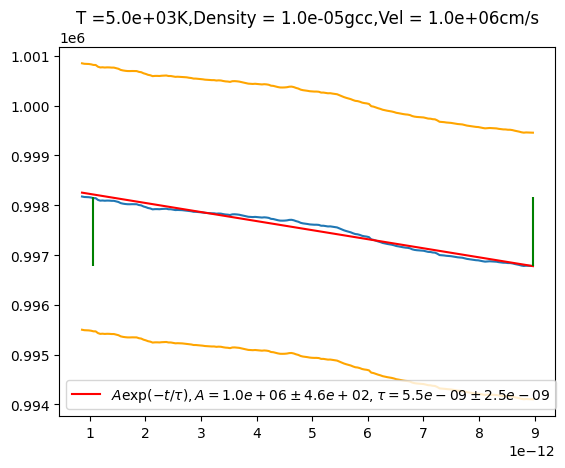

0 1
[1000337.96423593 1000205.45930004  999971.33428487 ...  326495.30594102
  326254.66415893  326011.66312546]


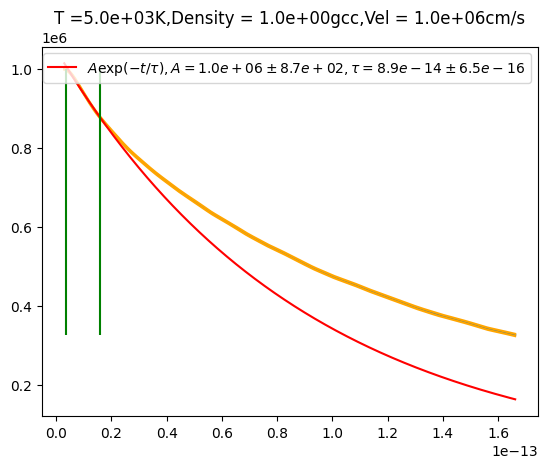

0 2
[987514.58402794 986840.22223622 986180.71792263 985561.24660445]


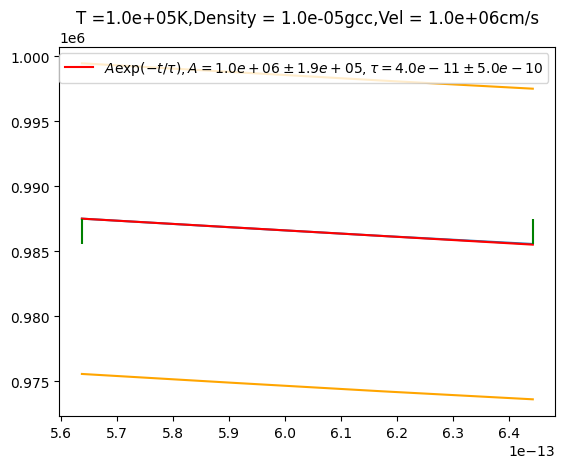

1 0
[9998165.23768537 9998163.98996122 9998163.88874294 9998163.70265649
 9998163.91905797 9998164.87338965 9998163.97278886 9998162.97090568
 9998164.18105048 9998163.17300429 9998164.37477265 9998163.4898722
 9998162.02579499 9998162.28542842 9998161.39377371 9998160.36950039
 9998159.8731982  9998158.96876108 9998158.5452     9998159.50971357
 9998159.12076062 9998157.78317701 9998156.81212415 9998158.88849783
 9998159.83791312 9998161.26386815 9998160.72036879 9998160.19511106
 9998160.6598408  9998160.41130838 9998158.56732604 9998159.21885681
 9998157.68062535 9998158.71648848 9998159.65609258 9998160.1443082
 9998161.05007799 9998161.1505012  9998160.81899735 9998162.32186847
 9998162.22543209 9998162.18267852 9998162.57616636 9998162.52896361
 9998163.22029833 9998163.08294589 9998163.60884852 9998163.23543982
 9998162.527717   9998161.3330304  9998161.802279   9998163.25285363
 9998163.55272058 9998164.13189733 9998162.1479676  9998162.66279607
 9998161.90235798 9998162.400395

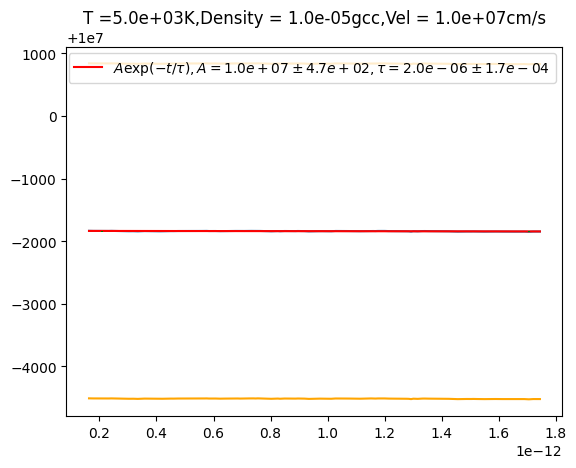

1 1
[9998873.30359735 9998756.51870108 9998540.90903498 ... 7981100.57938711
 7979318.76650819 7977535.65108591]


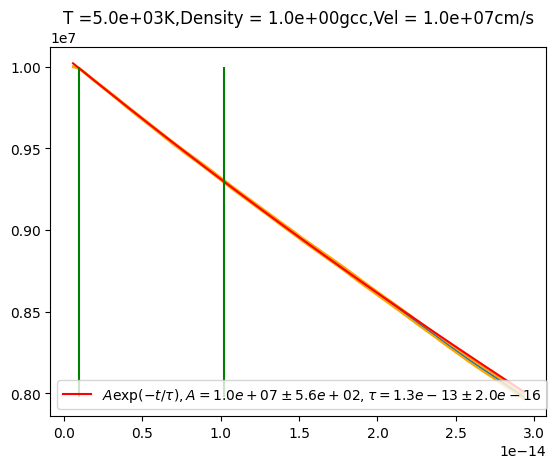

In [ ]:
gccarr =  np.array([1e-5,1,1e-5,1])
Tarr = np.array([5000,5000,1e5,1e5])
Z1arr = np.array([0.16,0.65,0.93,0.68])
Z2arr = np.array([0.26,3.82,4.27,3.81])
from scipy.optimize import curve_fit

def exp(time,m,b):
    return b*np.exp(-time/m)
for k in range(10,len(runlist)):
    run = runlist[k]
    print(run)
    folder = "../dataarchive/np{}/".format(runlist[k])
    velarr = veldict[run]
    results = -1*np.ones((4,len(velarr),6)) #4 cases, velocities, A, Aerr, tau, tauerr, start time, end time
    skip = thermdict[run]

    for i in range(len(velarr)):
        for j in range(len(casearr)):
            if  [i,j] not in dropdict[run]:
                print(i,j)
                vel = velarr[i]
                case = casearr[j]
                log = np.loadtxt(folder+"log_v{:.1e}_c{}.np".format(vel,case))
                force = np.loadtxt(folder+"force_v{:.1e}_c{}.np".format(vel,case))
                time = force[skip:,-1]
                data = force[skip:,:-1]
                plt.title("T ={:.1e}K,Density = {:.1e}gcc,Vel = {:.1e}cm/s".format(Tarr[j],gccarr[j],velarr[i]))
                mean = np.mean(data,axis=1)

                starti = min(np.argmin(np.abs(0.999*mean[0]-mean)),int(0.03*len(mean)))
                endi = max(np.argmin(np.abs(0.93*mean[0]-mean)),int(0.08*len(mean)))
                std = np.std(data,axis=1)/math.sqrt(2000)
                dt0 = time[-1]-time[0]
                plt.plot(time,mean)
                print(mean)
                popt, pcov = curve_fit(exp,time[starti:endi],mean[starti:endi],sigma =std[starti:endi],p0=[dt0,mean[0]*math.exp(-time[0]/dt0)],absolute_sigma=True,maxfev=2000)
                errors = np.sqrt(np.diag(pcov))
                results[j,i,:] = [popt[1],errors[1],popt[0],errors[0],time[starti],time[endi]]
                plt.plot(time,mean+std,color="orange")
                plt.plot(time,mean-std,color="orange")
                plt.plot(time,exp(time,popt[0],popt[1]),color="red",label=r"$A\exp(-t/\tau),A = {:.1e}\pm {:.1e}, \tau = {:.1e}\pm {:.1e}$".format(popt[1],errors[1],popt[0],errors[0]))
                plt.vlines([time[starti],time[endi]],ymin=np.min(mean),ymax=np.max(mean),color="green")
                plt.legend()
                plt.show()
    np.save("../dataarchive/np{}/results".format(run),results)

$$ v = A \exp(-t/\tau)$$
$$ a = -v/\tau$$
$$(\Delta v)^2 = \exp(-2t/\tau) (\Delta A^2) + \frac{t^2A^2}{\tau^4} \exp(-2t/\tau) (\Delta \tau^2)$$
$$(\Delta v)^2 = \frac{v^2}{A^2} (\Delta A^2) + \frac{t^2v^2}{\tau^4}  (\Delta \tau^2)$$
$$(\frac{\Delta a}{a})^2 = (\frac{\Delta v}{v})^2 + (\frac{\Delta \tau}{\tau})^2$$

# Overall Plot

..\..\theory\2026_05_06\theory_max_1.0e+02.npy
..\..\theory\2026_05_06\theory_max_1.0e+04.npy
..\..\theory\2026_05_06\theory_max_1.0e+05.npy
..\..\theory\2026_05_06\theory_max_1.0e+06.npy
..\..\theory\2026_05_06\theory_max_1.1e+04.npy
..\..\theory\2026_05_06\theory_max_1.2e+02.npy
..\..\theory\2026_05_06\theory_max_1.2e+03.npy
..\..\theory\2026_05_06\theory_max_1.3e+04.npy
..\..\theory\2026_05_06\theory_max_1.3e+05.npy
..\..\theory\2026_05_06\theory_max_1.4e+03.npy
..\..\theory\2026_05_06\theory_max_1.5e+02.npy
..\..\theory\2026_05_06\theory_max_1.5e+05.npy
..\..\theory\2026_05_06\theory_max_1.6e+04.npy
..\..\theory\2026_05_06\theory_max_1.7e+03.npy
..\..\theory\2026_05_06\theory_max_1.8e+02.npy
..\..\theory\2026_05_06\theory_max_1.8e+05.npy
..\..\theory\2026_05_06\theory_max_1.9e+04.npy
..\..\theory\2026_05_06\theory_max_2.0e+03.npy
..\..\theory\2026_05_06\theory_max_2.1e+02.npy
..\..\theory\2026_05_06\theory_max_2.2e+05.npy
..\..\theory\2026_05_06\theory_max_2.3e+04.npy
..\..\theory\

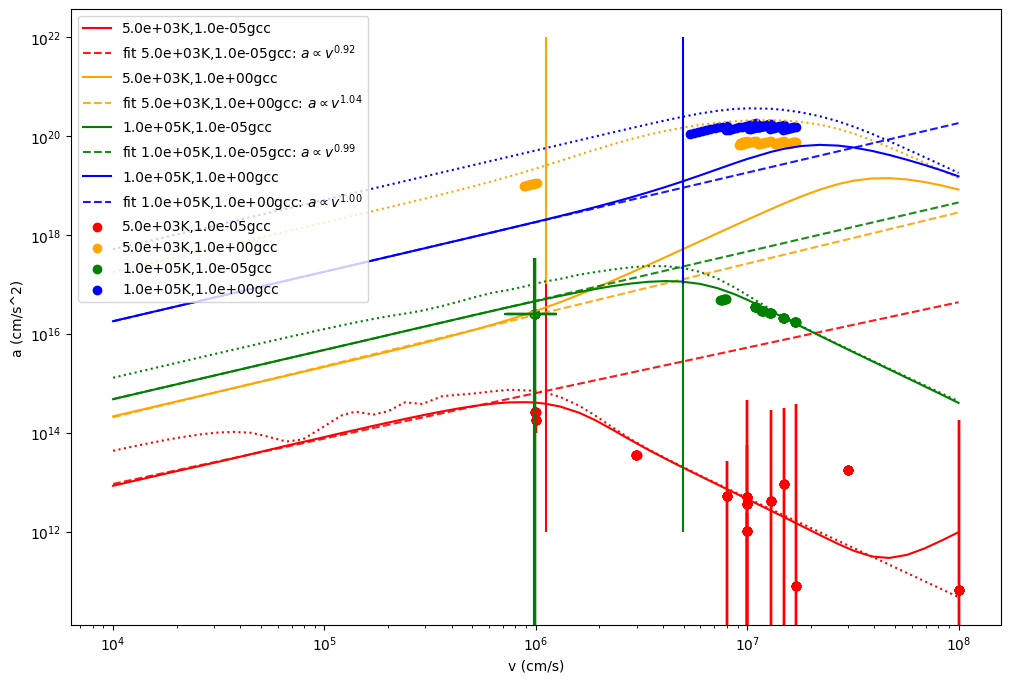

[[[0.00000000e+00 3.94168726e-15 0.00000000e+00]
  [0.00000000e+00 9.99549824e-14 0.00000000e+00]
  [0.00000000e+00 2.21960617e-13 0.00000000e+00]
  [0.00000000e+00 8.38903951e-12 0.00000000e+00]]

 [[0.00000000e+00 4.72128338e-15 0.00000000e+00]
  [0.00000000e+00 1.19945986e-13 0.00000000e+00]
  [0.00000000e+00 2.66345862e-13 0.00000000e+00]
  [0.00000000e+00 1.00668465e-11 0.00000000e+00]]

 [[0.00000000e+00 5.88152185e-15 0.00000000e+00]
  [0.00000000e+00 1.49932500e-13 0.00000000e+00]
  [0.00000000e+00 3.32916499e-13 0.00000000e+00]
  [0.00000000e+00 1.25835559e-11 0.00000000e+00]]

 [[0.00000000e+00 7.02844158e-15 0.00000000e+00]
  [0.00000000e+00 1.79919025e-13 0.00000000e+00]
  [0.00000000e+00 3.99476586e-13 0.00000000e+00]
  [0.00000000e+00 1.51002639e-11 0.00000000e+00]]

 [[0.00000000e+00 8.15944977e-15 0.00000000e+00]
  [0.00000000e+00 2.09905563e-13 0.00000000e+00]
  [0.00000000e+00 4.66024012e-13 0.00000000e+00]
  [0.00000000e+00 1.76169701e-11 0.00000000e+00]]

 [[0.00000

In [10]:
import scipy as scp
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

NA = 6.022e23
pi = 3.1415926535
me = 9.11e-31 #electron mass
ms = 28.0855e-3/NA #silicon mass kg
mh = 1.008e-3/NA
mu = ms*mh/(ms+mh)
qe = 1.6e-19
hbar = 6.626e-34
kb = 1.38e-23
e0 =  8.854e-12

casearr = np.array([0,1,2,3])


runlist = ["run10_15","run10_15b","run10_17","run10_18","run10_19","run10_22","run10_28","run11_5","run4_22"]
drop22 = [[0,0],[1,0],[4,0],[5,0],[6,0],[7,0],[8,0],[9,0]]
drop28=[]
for i in range(10):
    for j in range(1,4):
        drop22.append([i,j])
for i in range(2):
    for j in range(1,4):
        drop28.append([i,j])
drop115=[]
for i in range(2):
    for j in range(1,4):
        drop115.append([i,j])
drop45=[[0,1],[0,3],[2,1],[3,1]]
drop422=[[0,3],[1,2],[1,3]]
dropdict = {"run10_15":[[0,0],[0,1],[0,2],[1,2],[3,2],[4,2],[5,0],[5,1],[5,2],[5,3]],"run10_15b":[[0,0],[1,1],[1,2],[1,3],[2,0],[2,2],[2,3],[3,2],[3,3],[4,1],[4,2],[5,1],[5,2]],"run10_17":[[0,0],[1,3],[3,0],[3,1],[4,1],[4,2],[4,3],[5,1],[5,3],[6,2],[6,3]],"run10_18":[[0,2],[0,3],[1,0],[1,1],[3,2],[4,2],[5,1],[5,3]],"run10_19":[[0,0],[1,0],[1,1],[5,1]],"run10_22":drop22,"run10_28":drop28,"run11_5":drop115,"run4_15":drop45,"run4_22":drop422}#[[0,2],[1,0]]

thermdict = {"run10_15":81,"run10_15b":81,"run10_17":81,"run10_18":81,"run10_19":21,"run10_22":21,"run10_28":21,"run11_5":21,"run4_15":21,"run4_22":21}
veldict = {"run10_15":[2e7,3e7,4e7,5e7,6e7,8e7],"run10_15b":[1e2,1e3,1e4,1e5,1e6,1e7,1e8],"run10_17":[1.5e7,2e6,2.5e7,3e6,3.5e7,4.5e7,6e6,8e6],"run10_18":[1.5e6,2.5e6,4e6,5e6,7e6,9e6],"run10_19":[1.1e7,1.2e7,1.3e7,1.5e7,1.7e7,8e6],"run10_22":[1e4,1e5,1e7,1e8,2e5,2e6,3e5,3e6,6e5,6e6],"run10_28":[1e6,1e7],"run11_5":[3e6,3e7],"run4_15":[1e6,3e6,1e7,3e7],"run4_22":[1e6,1e7]}

Z1arr = np.array([0.16,0.65,0.93,0.68])
Z2arr = np.array([0.26,3.82,4.27,3.81])
gccarr =  np.array([1e-5,1,1e-5,1])
Tarr = np.array([5000,5000,1e5,1e5])

def ccs2(vrel,T,gcc,z1=0.648,z2=3.84):
    vcom = mh*vrel/(mh+ms)
    ne = 1e6*NA*z1*gcc/1.008
    ve = np.sqrt(3*kb*T/me)
    wp = np.sqrt(ne*(qe**2)/(me*e0))
    lD = ve/wp
    Tf = ((3*ne*(pi**2))**(2/3))*(hbar**2)/(2*me*kb)
    lS = lD*np.power(1+(2*Tf/(3*T)),1/4)
    k0 = 1/lS
    Aarr = (qe**2)*z1*z2/(4*pi*e0)
    Barr = 0.5*mh*((vrel-vcom)**2)+0.5*ms*((vcom)**2)
    Carr = Barr/Aarr
    rc = scp.special.lambertw(k0/Carr)/k0
    return pi*rc**2

def frel(vrel,vb,T):
    return np.sqrt(mu/(2*pi*kb*T))*np.exp(-mu*np.square(vrel-vb)/(2*kb*T))

def FDint(vbarr,A,T,gcc,zh,zs):
    n = 1e6*NA*gcc/1.008
    std = np.sqrt(kb*T/mu)
    result = np.zeros(len(vbarr))
    for i in range(len(vbarr)):
        vb = vbarr[i]
        vrel = np.linspace(vb-8*std,vb+8*std,2000)
        dvrel = vrel[1]-vrel[0]
        ccs = A*ccs2(vrel,T,gcc,zh,zs)
        result[i] = 2*mu*n*np.sum(ccs*vrel*np.abs(vrel)*frel(vrel,vb,T))*dvrel
    return result

def exp(time,tau,A):
    return A*np.exp(-time/tau)

def fit_power_law(x, y):
    """Fit y = C x^n using only positive finite data."""
    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    xfit = x[mask]
    yfit = y[mask]
    if len(xfit) < 2:
        return None, None, mask
    coeffs = np.polyfit(np.log10(xfit), np.log10(yfit), 1)
    n = coeffs[0]
    C = 10**coeffs[1]
    return C, n, mask

plt.figure(figsize=(12,8))
colors = ["red","orange","green","blue"]
labelled = [False,False,False,False]

count = 0
in_dir = Path("../../theory/2026_05_06")

files = sorted(in_dir.glob("theory_max*.npy"))
dragarr = np.zeros((len(files),4,3))
velarr = np.zeros(len(files))

for count, p in enumerate(files):
    print(p)
    velarr[count] = float(str(p).split("_")[4].split(".npy")[0])
    dragarr[count,:,:] = np.load(p)

indices = velarr.argsort()
dragarr = dragarr[indices,:,:]
velarr = velarr[indices]

# in_dir = Path("../../theory")
# files = sorted(in_dir.glob("theory_diagnostics*.npy"))
# dragarr2 = np.zeros((len(files),4,3))
# velarr2 = np.zeros(len(files))

# for count, p in enumerate(files):
#     print(p)
#     velarr2[count] = float(str(p).split("_")[2].split(".npy")[0])
#     dragarr2[count,:,:] = np.load(p)

# indices = velarr2.argsort()
# dragarr2 = dragarr2[indices,:,:]
# velarr2 = velarr2[indices]

np.save("../../theory/2026_05_06/DBdrag",dragarr)
np.save("../../theory/2026_05_06/DBvel",velarr)

def gurnett(vrel,T,gcc,z1=0.648,z2=3.84):
    vrel = np.asarray(vrel, dtype=float)
    nH = gcc*1000/(1.008e-3)*NA
    ne = z1*nH
    vth = np.sqrt(2*kb*T/mh)
    y = np.abs(vrel)/vth
    lD = np.sqrt(e0*kb*T/(ne*qe**2))
    b90 = np.abs(z1*z2)*qe**2/((4*pi*e0)*mu*vrel**2)
    lnL = np.log(lD/b90)
    bracket = scp.special.erf(y) - (2*y/np.sqrt(pi))*np.exp(-y**2)
    pref = nH * ((z1*z2*qe**2)/(4*pi*e0))**2 * lnL / (ms*mu)

    a = np.zeros_like(vrel)
    mask = np.abs(vrel) > 0
    a[mask] = pref[mask] * bracket[mask] / (vrel[mask]**2)
    a[mask] *= np.sign(vrel[mask])
    print(a)
    return a

olddrag=np.load("../../theory/2026_05_06/olddrag.npy")
oldvel=np.load("../../theory/2026_05_06/oldvel.npy")
# ---- line-plotted theory data + power-law fits ----
for i in range(4):
    if i % 2 == 0:
        plt.vlines(x=100*np.sqrt(3*kb*Tarr[i]/mh), ymin=1e12, ymax=1e17, color=colors[i])
    else:
        plt.vlines(x=100*np.sqrt(3*kb*Tarr[i]/mh), ymin=1e17, ymax=1e22, color=colors[i])

    x_line = velarr * 100
    y_line = 100 * dragarr[:,i,1] / ms
    plt.plot(oldvel*100,olddrag[:,i,1]*100/ms,color=colors[i],linestyle=":")
    plt.plot(x_line, y_line, color=colors[i],
             label="{:.1e}K,{:.1e}gcc".format(Tarr[i],gccarr[i]))

    C, n, mask = fit_power_law(x_line[:int(len(velarr)/2)], y_line[:int(len(velarr)/2)])
    if C is not None:
        x_fit = x_line
        y_fit = C * x_fit**n
        plt.plot(
            x_fit, y_fit,
            linestyle="--",
            color=colors[i],
            alpha=0.9,
            label=r"fit {:.1e}K,{:.1e}gcc: $a \propto v^{{{:.2f}}}$".format(Tarr[i], gccarr[i], n)
        )

# ---- scatter-plotted simulation data, unchanged and NOT fitted ----
for k in range(4,9):
    run = runlist[k]
    print(run)
    results = np.load("../dataarchive/np{}/results.npy".format(run))
    print(results)
    velarr_run = veldict[run]

    for i in range(4):
        for j in range(len(velarr_run)):
            print(results)
            if results[i,j,5] != -1:
                count += 1
                startt = results[i,j,4]
                endt = results[i,j,5]
                tarr = np.linspace(startt, endt, 10)
                A = results[i,j,0]
                eA = results[i,j,1]
                tau = results[i,j,2]
                etau = results[i,j,3]
                varr = exp(tarr, tau, A)
                aarr = varr/tau
                verr = np.sqrt(np.square(varr*eA/A) + np.square(tarr*varr*etau/np.square(tau)))
                aerr = aarr*np.sqrt(np.square(verr/varr) + np.square(etau/tau))

                if labelled[i]:
                    plt.scatter(varr, aarr, color=colors[i])
                    plt.errorbar(varr, aarr, xerr=verr, yerr=aerr, color=colors[i])
                else:
                    plt.scatter(varr, aarr, color=colors[i],
                                label="{:.1e}K,{:.1e}gcc".format(Tarr[i],gccarr[i]))
                    plt.errorbar(varr, aarr, xerr=verr, yerr=aerr, color=colors[i])
                    labelled[i] = True

print(count)
plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.xlabel("v (cm/s)")
plt.ylabel("a (cm/s^2)")
plt.show()
print(dragarr)

# Fit Theory

..\..\theory_max_1.0e+02.npy
..\..\theory_max_1.0e+04.npy
..\..\theory_max_1.0e+05.npy
..\..\theory_max_1.0e+06.npy
..\..\theory_max_1.1e+04.npy
..\..\theory_max_1.2e+02.npy
..\..\theory_max_1.2e+03.npy
..\..\theory_max_1.3e+04.npy
..\..\theory_max_1.3e+05.npy
..\..\theory_max_1.4e+03.npy
..\..\theory_max_1.5e+02.npy
..\..\theory_max_1.5e+05.npy
..\..\theory_max_1.6e+04.npy
..\..\theory_max_1.7e+03.npy
..\..\theory_max_1.8e+02.npy
..\..\theory_max_1.8e+05.npy
..\..\theory_max_1.9e+04.npy
..\..\theory_max_2.0e+03.npy
..\..\theory_max_2.1e+02.npy
..\..\theory_max_2.2e+05.npy
..\..\theory_max_2.3e+04.npy
..\..\theory_max_2.4e+03.npy
..\..\theory_max_2.6e+02.npy
..\..\theory_max_2.7e+05.npy
..\..\theory_max_2.8e+04.npy
..\..\theory_max_2.9e+03.npy
..\..\theory_max_3.1e+02.npy
..\..\theory_max_3.2e+05.npy
..\..\theory_max_3.4e+04.npy
..\..\theory_max_3.6e+03.npy
..\..\theory_max_3.7e+02.npy
..\..\theory_max_3.9e+05.npy
..\..\theory_max_4.1e+04.npy
..\..\theory_max_4.3e+03.npy
..\..\theory_m

C:\Users\shaoq\AppData\Local\Temp\ipykernel_42968\784343510.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  result[i] = 2*mu*n*np.sum(ccs*vrel*np.abs(vrel)*frel(vrel,vb,T))*dvrel#/np.sum(frel(vrel,vb,T))


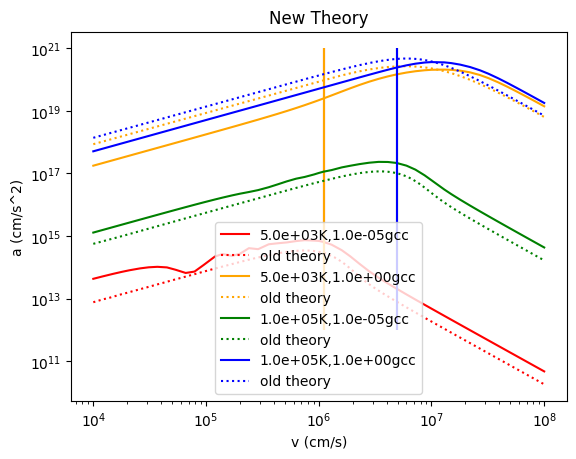

In [6]:
#!/usr/bin/env python3
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
gccarr =  np.array([1e-5,1,1e-5,1],dtype=np.float64)
Tarr = np.array([5000,5000,1e5,1e5],dtype=np.float64)
in_dir = Path("../../")
NA = 6.022e23
pi = 3.1415926535
me = 9.11e-31 #electron mass
ms = 28.0855*0.001/NA
files = sorted(in_dir.glob("theory_max*.npy"))
arrs = [np.load(p) for p in files]

dragarr =np.zeros((len(arrs),4,3))
velarr = np.zeros(len(arrs))
count = 0
for p in files:
    print(p)
    velarr[count]=float(str(p).split("_")[2].split(".npy")[0])
    dragarr[count,:,:] = np.load(p)
    count+=1
indices= velarr.argsort()
dragarr = dragarr[indices,:,:]
velarr = velarr[indices]
print(dragarr)
colors=["red","orange","green","blue"]

for i in range(4):
    plt.vlines(x=100*np.sqrt(3*kb*Tarr[i]/mh),ymin=1e12,ymax=1e21,color=colors[i])
    plt.plot(velarr*100,100*dragarr[:,i,1]/ms,color=colors[i],label="{:.1e}K,{:.1e}gcc".format(Tarr[i],gccarr[i]))
    plt.plot(xarr,100*np.abs(FDint(xarr/100,1,Tarr[i],gccarr[i],Z1arr[i],Z2arr[i]))/ms, linestyle=":",color=colors[i],label="old theory")

plt.legend()
# plt.ylim(1e11,1e22)
plt.xscale("log")
plt.title("New Theory")
plt.yscale("log")
plt.xlabel("v (cm/s)")
# plt.ylabel("collision cross section")

plt.ylabel("a (cm/s^2)")
plt.show()

In [2]:
#!/usr/bin/env python3
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
in_dir = Path("../../theory/calculation")
NA = 6.022e23
pi = 3.1415926535
me = 9.11e-31 #electron mass
ms = 28.0855*0.001/NA
files = sorted(in_dir.glob("theory_head_on_*.npy"))
arrs = [np.load(p) for p in files]

dragarr =np.zeros((len(arrs),5))
count = 0
for p in files:
    dragarr[count,0]=float(str(p).split("_")[1].split(".npy")[0])
    dragarr[count,1:] = np.load(p)
    count+=1
indices= dragarr[:,0].argsort()
dragarr = dragarr[indices]
print(dragarr)
colors=["red","orange","green","blue"]

for i in range(4):
    plt.plot(dragarr[:,0]*100,100*dragarr[:,1+i]/ms,color=colors[i],label="{:.1e}K,{:.1e}gcc".format(Tarr[i],gccarr[i]))
    plt.plot(xarr,100*np.abs(FDint(xarr/100,1,Tarr[i],gccarr[i],Z1arr[i],Z2arr[i]))/ms, linestyle=":",color=colors[i],label="old theory")

plt.legend()
# plt.ylim(1e11,1e22)
plt.xscale("log")
plt.title("New Theory")
plt.yscale("log")
plt.xlabel("v (cm/s)")
plt.ylabel("a (cm/s^2)")
plt.show()

[]


NameError: name 'Tarr' is not defined